# Bowel Sound Dataset Explorer

Interactive notebook to:
1. Load a subset of the dataset
2. Pick a random sample from a chosen class (`b`, `mb`, or `h`)
3. Listen to it and inspect its waveform + spectrogram
4. Visualise the effect of **peak normalisation** (before vs after)

---
**Only one cell needs editing:** Cell 4 — set `chosen_class` and optionally `random_seed`.

## 1 · Imports

In [17]:
import sys
import random
import warnings
from pathlib import Path
from collections import defaultdict

# Add project root so local modules resolve
PROJECT_ROOT = "/home/digihealth project"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import Audio, display

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from config import get_config
from src.dataset import load_audio_files, build_segments, ANNOTATION_MAP

print("Imports OK")

Imports OK


## 2 · Load config and data

`load_audio_files` peak-normalises each **full recording** to `[-1, 1]`.
We also load the raw (un-normalised) waveforms separately for the comparison in Section 5.

In [18]:
cfg      = get_config()
data_dir = Path(cfg.data.data_dir)
SR       = cfg.data.sample_rate  # 16 000 Hz

# ── Recording-level peak-normalised waveforms (used by the training pipeline) ─
print("Loading peak-normalised audio...")
waveforms_norm = load_audio_files(data_dir, target_sr=SR)

# ── Raw waveforms (no normalisation) ─────────────────────────────────────────
def _load_raw(wav_name: str) -> np.ndarray:
    """Load a recording at target SR without any amplitude normalisation."""
    wav_path = data_dir / wav_name
    audio, native_sr = sf.read(str(wav_path), dtype="float32", always_2d=False)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    if native_sr != SR:
        audio = librosa.resample(audio, orig_sr=native_sr, target_sr=SR,
                                 res_type="kaiser_best")
    return audio.astype(np.float32)

print("Loading raw (un-normalised) audio...")
waveforms_raw = {name: _load_raw(name) for name in ANNOTATION_MAP if (data_dir / name).exists()}

for name, wav in waveforms_norm.items():
    raw = waveforms_raw[name]
    print(f"\n{name}")
    print(f"  duration : {len(wav)/SR:.1f} s  ({len(wav):,} samples)")
    print(f"  raw  peak: {np.abs(raw).max():.6f}   rms: {np.sqrt(np.mean(raw**2)):.6f}")
    print(f"  norm peak: {np.abs(wav).max():.6f}   rms: {np.sqrt(np.mean(wav**2)):.6f}")

# ── Segments ──────────────────────────────────────────────────────────────────
print("\nParsing segments...")
import logging
logging.disable(logging.CRITICAL)   # silence the INFO spam from build_segments
segments = build_segments(data_dir, cfg.data)
logging.disable(logging.NOTSET)

segments_by_class: dict[str, list] = defaultdict(list)
for seg in segments:
    segments_by_class[seg.label_name].append(seg)

print("\nClass counts:")
for cls in sorted(segments_by_class):
    print(f"  {cls}: {len(segments_by_class[cls])} segments")

Loading peak-normalised audio...
Loading raw (un-normalised) audio...

AS_1.wav
  duration : 2212.4 s  (35,398,753 samples)
  raw  peak: 1.000000   rms: 0.125868
  norm peak: 1.000000   rms: 0.125868

23M74M.wav
  duration : 300.6 s  (4,809,387 samples)
  raw  peak: 0.530308   rms: 0.010137
  norm peak: 1.000000   rms: 0.019115

Parsing segments...

Class counts:
  b: 1113 segments
  h: 109 segments
  mb: 1004 segments


In [19]:
# ── Parse ALL annotation labels (no filtering — includes n, v, sb, sbs) ───────
from src.dataset import Segment as _Segment

def _parse_all_raw(data_dir, annotation_map):
    """Return every annotation segment with its raw label, nothing filtered out."""
    segs = []
    for wav_name, txt_name in annotation_map.items():
        txt_path = Path(data_dir) / txt_name
        if not txt_path.exists():
            continue
        for line in txt_path.read_text(encoding="utf-8", errors="replace").splitlines():
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 3:
                continue
            try:
                start, end = float(parts[0]), float(parts[1])
            except ValueError:
                continue
            raw_label = parts[2].strip()
            segs.append(_Segment(
                start=start, end=end,
                label=cfg.data.label_map.get(raw_label, -1),
                source=wav_name,
                label_name=raw_label,   # keep the original label string
            ))
    return segs

_all_raw = _parse_all_raw(data_dir, ANNOTATION_MAP)

segments_by_raw_label = defaultdict(list)
for _s in _all_raw:
    segments_by_raw_label[_s.label_name].append(_s)

# Canonical ordering: target labels first, then ignored ones, then anything else
_LABEL_ORDER = ["b", "sb", "sbs", "mb", "h", "n", "v"]
_extra = sorted(k for k in segments_by_raw_label if k not in _LABEL_ORDER)
ALL_LABELS = [l for l in _LABEL_ORDER if l in segments_by_raw_label] + _extra

print(f"  {'label':<6}  {'count':>5}  training status")
print(f"  {'─'*6}  {'─'*5}  {'─'*35}")
for lbl in ALL_LABELS:
    cnt = len(segments_by_raw_label[lbl])
    if lbl in cfg.data.ignore_labels:
        status = "ignored  (excluded from training)"
    elif lbl in cfg.data.label_map:
        canonical = {0: "b", 1: "mb", 2: "h"}[cfg.data.label_map[lbl]]
        status = f"target   → canonical class '{canonical}'"
    else:
        status = "unknown"
    print(f"  {lbl:<6}  {cnt:>5}  {status}")

  label   count  training status
  ──────  ─────  ───────────────────────────────────
  b         858  target   → canonical class 'b'
  sb        254  target   → canonical class 'b'
  sbs         1  target   → canonical class 'b'
  mb       1004  target   → canonical class 'mb'
  h         109  target   → canonical class 'h'
  n         105  ignored  (excluded from training)
  v         118  ignored  (excluded from training)


## 3 · Clip helper

In [20]:
CONTEXT_S = 0.5  # seconds of padding around each event

def extract_clip(waveform: np.ndarray, seg, cfg_data=None,
                 context_s: float = CONTEXT_S) -> np.ndarray:
    """Extract [seg.start - context_s, seg.end + context_s] from waveform."""
    start = max(0, int((seg.start - context_s) * SR))
    end   = min(len(waveform), int((seg.end + context_s) * SR))
    return waveform[start:end].copy()


def event_region_in_clip(seg, cfg_data=None,
                         context_s: float = CONTEXT_S) -> tuple[float, float]:
    """Return (start_ms, end_ms) of the event window inside the extracted clip."""
    pad_samples  = int(context_s * SR)
    event_start  = max(0, int(seg.start * SR))
    clip_start   = max(0, event_start - pad_samples)
    offset       = event_start - clip_start          # samples before event
    event_dur    = int((seg.end - seg.start) * SR)
    win_start_ms = offset / SR * 1000
    win_end_ms   = (offset + event_dur) / SR * 1000
    return win_start_ms, win_end_ms


print("Clip helper defined.")

Clip helper defined.


---
## 4 · Interactive explorer

**Controls:**
- **Class** dropdown → picks a new random clip from that class automatically
- **🎲 New clip** button → picks another random clip from the same class
- **Augmentation** dropdown → applies the chosen transform to the current clip (no new pick)

The output always shows **Original** alongside the **augmented** version (waveform + spectrogram + audio player for each).

> `seg` is exposed as a global variable after the first interaction so the peak-normalisation section below can use it directly.

In [21]:
import ipywidgets as widgets
from IPython.display import clear_output, display, Audio
from src.augmentation import time_stretch, pitch_shift, waveform_mask, augment_waveform

# ── Shared mutable state ───────────────────────────────────────────────────────
_state = {"seg": None, "base": None, "seed": 0}

# ── Augmentation catalogue ─────────────────────────────────────────────────────
_AUG_OPTIONS = [
    ("— none (original only) —",    "none"),
    ("Time stretch  ×0.85  (slow)", "ts_slow"),
    ("Time stretch  ×1.15  (fast)", "ts_fast"),
    ("Pitch shift   +2 st",         "ps_up"),
    ("Pitch shift   −2 st",         "ps_down"),
    ("Waveform mask  (2 blocks)",   "mask"),
    ("All combined  (stochastic)",  "all"),
]

def _apply_aug(base, aug_key, seed):
    rng = np.random.default_rng(seed)
    if aug_key == "none":
        return base.copy(), "Original"
    if aug_key == "ts_slow":
        return time_stretch(base, rate=0.85, sr=SR), "Time stretch ×0.85 (slow)"
    if aug_key == "ts_fast":
        return time_stretch(base, rate=1.15, sr=SR), "Time stretch ×1.15 (fast)"
    if aug_key == "ps_up":
        return pitch_shift(base, n_steps=+2.0, sr=SR), "Pitch shift +2 st"
    if aug_key == "ps_down":
        return pitch_shift(base, n_steps=-2.0, sr=SR), "Pitch shift −2 st"
    if aug_key == "mask":
        return waveform_mask(
            base,
            num_masks=cfg.augmentation.spec_augment_num_masks,
            max_mask_samples=cfg.augmentation.spec_augment_max_mask_samples,
            rng=rng,
        ), "Waveform mask (2 blocks)"
    if aug_key == "all":
        return augment_waveform(
            base, sr=SR,
            p_time_stretch=1.0, p_pitch_shift=1.0,
            time_stretch_range=cfg.augmentation.time_stretch_range,
            pitch_shift_range=cfg.augmentation.pitch_shift_range,
            num_masks=cfg.augmentation.spec_augment_num_masks,
            max_mask_samples=cfg.augmentation.spec_augment_max_mask_samples,
            rng=rng,
        ), f"All combined (seed={seed})"
    return base.copy(), "?"


def _plot_pair(base, augmented, aug_label, seg, show_both):
    win_s, win_e = event_region_in_clip(seg, cfg.data)
    t_ms  = np.arange(len(base)) / SR * 1000
    ncols = 2 if show_both else 1

    fig, axes = plt.subplots(
        2, ncols,
        figsize=(14 if show_both else 8, 6.5),
        gridspec_kw={"hspace": 0.5, "wspace": 0.35},
    )
    if ncols == 1:
        axes = axes.reshape(2, 1)

    clips = [("Original", base, "#444444")]
    if show_both:
        clips.append((aug_label, augmented, "#d62728"))

    for col, (label, c, color) in enumerate(clips):
        ax_w, ax_s = axes[0, col], axes[1, col]

        ax_w.plot(t_ms, c, lw=0.7, color=color)
        ax_w.axvspan(win_s, win_e, alpha=0.15, color="gold",
                     label="Event + context" if col == 0 else None)
        ax_w.axhline(0, color="gray", lw=0.4, ls="--")
        ax_w.set_ylim(-1.15, 1.15)
        ax_w.set_title(label, fontsize=11, fontweight="bold", color=color)
        ax_w.set_xlabel("Time (ms)", fontsize=9)
        ax_w.set_ylabel("Amplitude", fontsize=9)
        ax_w.tick_params(labelsize=8)
        if col == 0:
            ax_w.legend(fontsize=8, loc="upper right")

        D = librosa.amplitude_to_db(
            np.abs(librosa.stft(c, n_fft=512, hop_length=128)), ref=np.max
        )
        img = librosa.display.specshow(
            D, sr=SR, hop_length=128, x_axis="ms", y_axis="hz",
            ax=ax_s, cmap="magma", vmin=-80, vmax=0,
        )
        ax_s.set_ylim(0, SR // 2)
        ax_s.set_xlabel("Time (ms)", fontsize=9)
        ax_s.tick_params(labelsize=8)
        plt.colorbar(img, ax=ax_s, format="%+2.0f dB", pad=0.02)

    fig.suptitle(
        f"raw label = {seg.label_name}  │  {seg.source}  │  "
        f"{seg.start:.3f}–{seg.end:.3f} s  ({seg.duration*1000:.0f} ms)",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    return fig


def _training_tag(raw_lbl):
    if raw_lbl in cfg.data.ignore_labels:
        return "IGNORED in training"
    if raw_lbl in cfg.data.label_map:
        canonical = {0: "b", 1: "mb", 2: "h"}[cfg.data.label_map[raw_lbl]]
        return f"trains as '{canonical}'"
    return "unknown label"


def _render():
    global seg
    if _state["seg"] is None:
        return
    seg     = _state["seg"]
    base    = _state["base"]
    aug_key = aug_dd.value
    augmented, aug_label = _apply_aug(base, aug_key, _state["seed"])
    show_both = aug_key != "none"

    with out:
        clear_output(wait=True)
        print(
            f"  Source: {seg.source}  │  Label: {seg.label_name}"
            f"  [{_training_tag(seg.label_name)}]  │  "
            f"{seg.start:.3f}–{seg.end:.3f} s  ({seg.duration*1000:.0f} ms)  │  "
            f"peak: {np.abs(base).max():.4f}   seed: {_state['seed']}"
        )
        fig = _plot_pair(base, augmented, aug_label, seg, show_both)
        plt.show()
        print("\n🔊  Original")
        display(Audio(base, rate=SR))
        if show_both:
            print(f"\n🔊  {aug_label}")
            display(Audio(augmented, rate=SR))


def _pick_new(_=None):
    pool = segments_by_raw_label[class_dd.value]
    s    = random.choice(pool)
    _state["seg"]  = s
    _state["base"] = extract_clip(waveforms_norm[s.source], s, cfg.data)
    _state["seed"] = random.randint(0, 9_999)
    _render()


# ── Build dropdown options with counts and training-status tags ────────────────
def _class_options():
    opts = []
    for lbl in ALL_LABELS:
        cnt = len(segments_by_raw_label[lbl])
        if lbl in cfg.data.ignore_labels:
            tag = "  [ignored]"
        elif lbl in ("sb", "sbs"):
            tag = "  [→ b]"
        else:
            tag = ""
        opts.append((f"{lbl}  ({cnt}){tag}", lbl))
    return opts


class_dd = widgets.Dropdown(
    options=_class_options(),
    value=ALL_LABELS[0],
    description="Label:",
    layout=widgets.Layout(width="240px"),
    style={"description_width": "50px"},
)
aug_dd = widgets.Dropdown(
    options=_AUG_OPTIONS,
    value="none",
    description="Augmentation:",
    layout=widgets.Layout(width="310px"),
    style={"description_width": "110px"},
)
new_btn = widgets.Button(
    description="🎲  New clip",
    button_style="primary",
    layout=widgets.Layout(width="120px", height="32px"),
)
out = widgets.Output()

class_dd.observe(lambda ch: _pick_new() if ch["name"] == "value" else None, "value")
aug_dd.observe(  lambda ch: _render()   if ch["name"] == "value" else None, "value")
new_btn.on_click(_pick_new)

controls = widgets.HBox(
    [class_dd, new_btn, aug_dd],
    layout=widgets.Layout(gap="14px", align_items="center", margin="0 0 10px 0"),
)
display(widgets.VBox([controls, out]))
_pick_new()

---
## 5 · Peak normalisation: before vs after

> **Prerequisite:** Run the interactive cell (Section 4) at least once — it sets the global `seg` variable used here.

**What happens at each stage:**

| Stage | What it is | Where it happens |
|---|---|---|
| **Raw** | Waveform straight from the `.wav` file (float32, bit-depth normalised by soundfile) | `sf.read` |
| **Recording-level peak norm** | Entire recording ÷ its own max absolute value → `[-1, 1]` | `load_audio_files()` |
| **Clip-level peak norm** | Extracted clip ÷ its own max absolute value → `[-1, 1]` | applied below |

The training pipeline uses the **recording-level** normalised waveform.
Wav2Vec2Processor then applies **zero-mean / unit-variance** normalisation on top.

In [22]:
# ── Extract the same clip at each normalisation stage ─────────────────────────
clip_raw      = extract_clip(waveforms_raw[seg.source],  seg, cfg.data)   # raw
clip_rec_norm = extract_clip(waveforms_norm[seg.source], seg, cfg.data)   # recording-level norm

peak_clip = np.abs(clip_rec_norm).max()
clip_clip_norm = clip_rec_norm / peak_clip if peak_clip > 0 else clip_rec_norm.copy()  # clip-level norm

# Summary statistics
recording_peak = np.abs(waveforms_raw[seg.source]).max()

print(f"Recording peak (used by load_audio_files) : {recording_peak:.6f}")
print()
for name, c in [("RAW clip", clip_raw),
                ("Rec-norm clip", clip_rec_norm),
                ("Clip-norm clip", clip_clip_norm)]:
    nonzero = c[np.abs(c) > 1e-7]
    nz_rms = f"{np.sqrt(np.mean(nonzero**2)):.6f}" if len(nonzero) else "n/a"
    print(f"{name:<18}  peak={np.abs(c).max():.6f}  "
          f"rms={np.sqrt(np.mean(c**2)):.8f}  "
          f"nonzero_rms={nz_rms}")

Recording peak (used by load_audio_files) : 1.000000

RAW clip            peak=0.137421  rms=0.05101139  nonzero_rms=0.051014
Rec-norm clip       peak=0.137421  rms=0.05101139  nonzero_rms=0.051014
Clip-norm clip      peak=1.000000  rms=0.37120613  nonzero_rms=0.371226


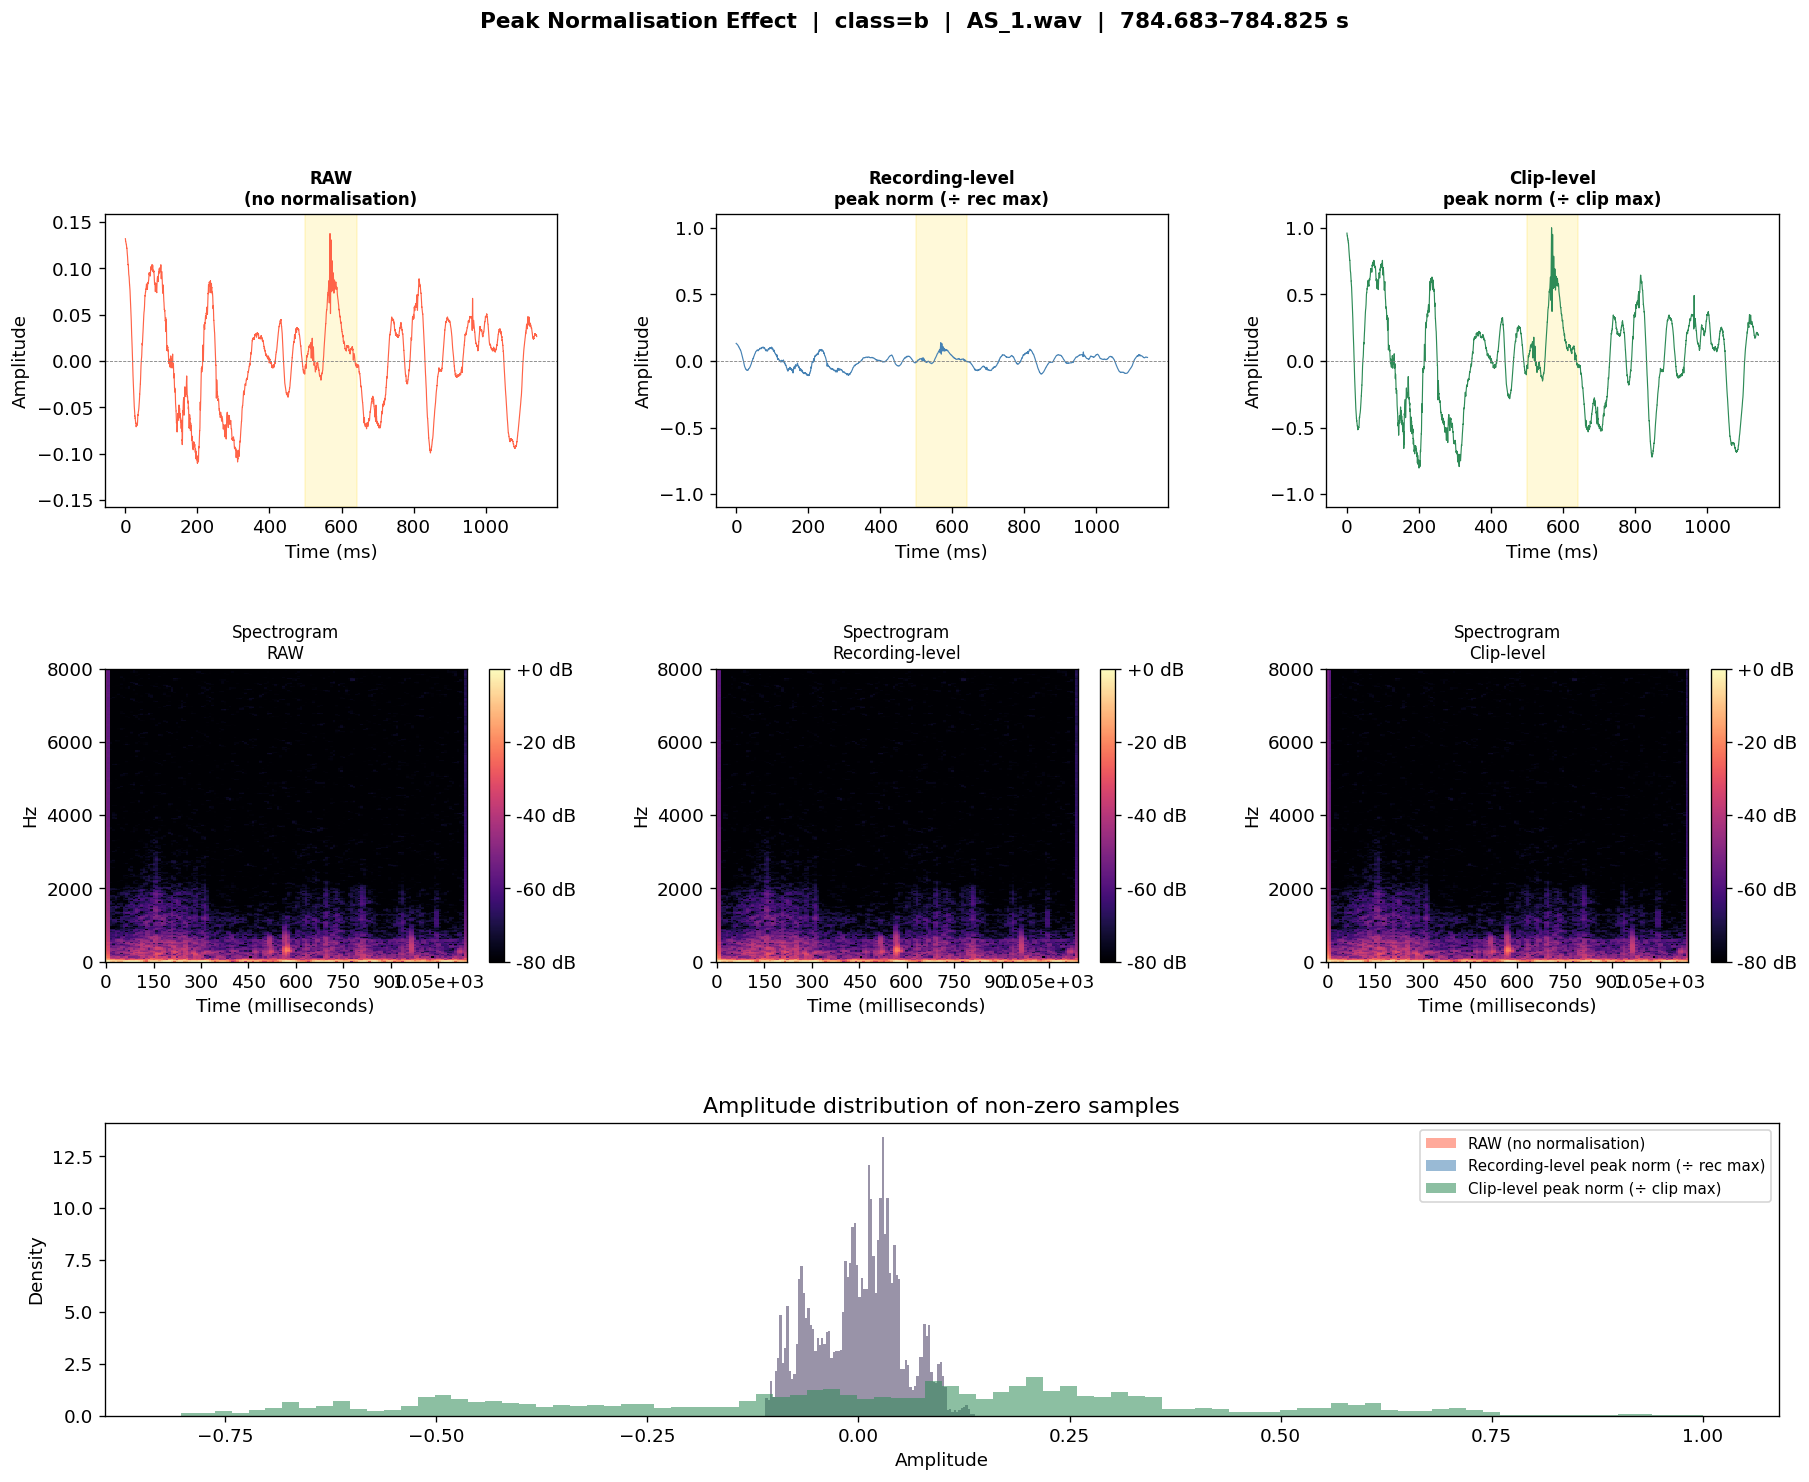

Saved: peak_norm_comparison.png


In [23]:
# ── Comparison figure ─────────────────────────────────────────────────────────
t_ms = np.arange(len(clip_raw)) / SR * 1000
win_start_ms, win_end_ms = event_region_in_clip(seg, cfg.data)

stages = [
    (clip_raw,       "RAW\n(no normalisation)",              "tomato",    None),
    (clip_rec_norm,  "Recording-level\npeak norm (÷ rec max)", "steelblue", (-1.1, 1.1)),
    (clip_clip_norm, "Clip-level\npeak norm (÷ clip max)",    "seagreen",  (-1.1, 1.1)),
]

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# Row 0 — waveforms
y_raw_lim = np.abs(clip_raw).max() * 1.15
for col, (data, title, color, ylim) in enumerate(stages):
    ax = fig.add_subplot(gs[0, col])
    ax.plot(t_ms, data, lw=0.7, color=color)
    ax.axvspan(win_start_ms, win_end_ms, alpha=0.15, color="gold")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude")
    if ylim:
        ax.set_ylim(*ylim)
    else:
        ax.set_ylim(-y_raw_lim, y_raw_lim)

# Row 1 — spectrograms
for col, (data, title, color, _) in enumerate(stages):
    ax = fig.add_subplot(gs[1, col])
    D = librosa.amplitude_to_db(
        np.abs(librosa.stft(data, n_fft=512, hop_length=128)), ref=np.max
    )
    img = librosa.display.specshow(
        D, sr=SR, hop_length=128, x_axis="ms", y_axis="hz", ax=ax, cmap="magma"
    )
    ax.set_title(f"Spectrogram\n{title.splitlines()[0]}", fontsize=10)
    ax.set_ylim(0, SR // 2)
    plt.colorbar(img, ax=ax, format="%+2.0f dB")

# Row 2 — amplitude histograms (non-zero samples only)
ax_hist = fig.add_subplot(gs[2, :])
for data, title, color, _ in stages:
    nz = data[np.abs(data) > 1e-7]
    label = title.replace("\n", " ")
    ax_hist.hist(nz, bins=90, alpha=0.55, color=color, label=label, density=True)
ax_hist.set_xlabel("Amplitude")
ax_hist.set_ylabel("Density")
ax_hist.set_title("Amplitude distribution of non-zero samples")
ax_hist.legend(fontsize=9)

fig.suptitle(
    f"Peak Normalisation Effect  |  class={seg.label_name}  |  "
    f"{seg.source}  |  {seg.start:.3f}–{seg.end:.3f} s",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.savefig("peak_norm_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: peak_norm_comparison.png")

### Listen to each normalisation stage

In [24]:
for label, clip in [
    ("RAW (no normalisation)",          clip_raw),
    ("Recording-level peak normalised", clip_rec_norm),
    ("Clip-level peak normalised",      clip_clip_norm),
]:
    print(f"\n=== {label} ===")
    display(Audio(clip, rate=SR))


=== RAW (no normalisation) ===



=== Recording-level peak normalised ===



=== Clip-level peak normalised ===


---
## 6 · Browse multiple samples at once

Run this cell to see a grid of **N** random samples from any class, each with its own waveform.
Useful for getting a feel for intra-class variability.

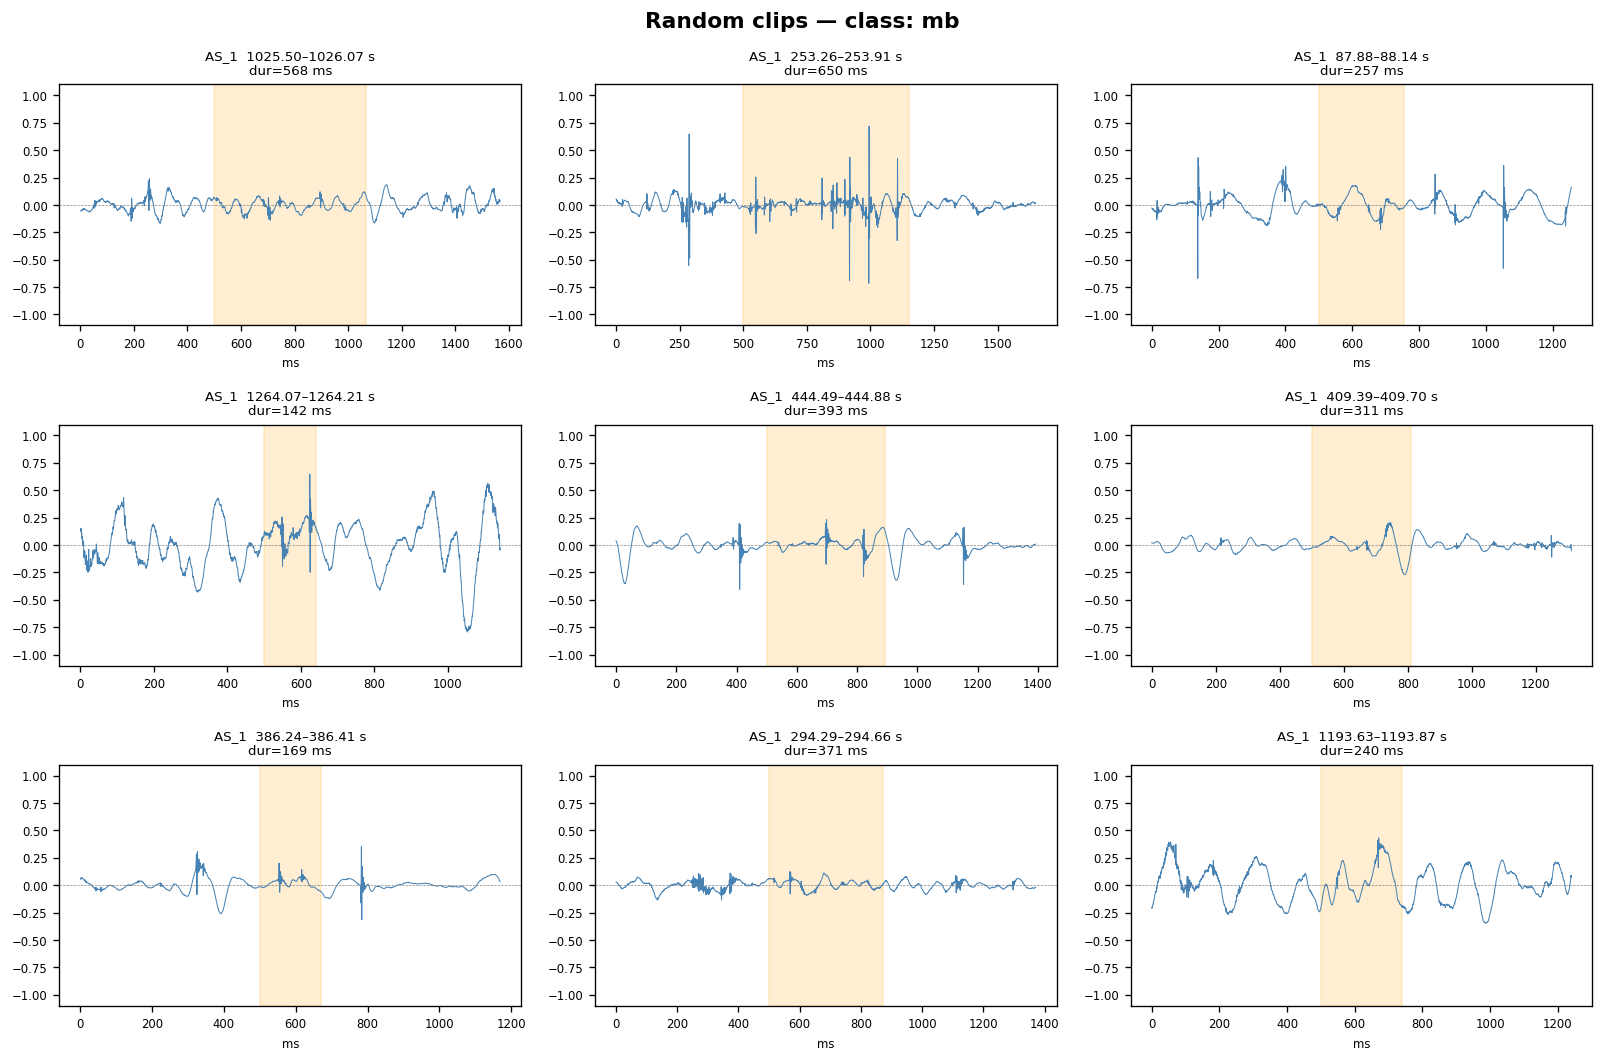

Saved: browse_mb.png


In [31]:
# ╔══════════════════════════════════════════════════╗
# ║  EDIT HERE                                       ║
# ╠══════════════════════════════════════════════════╣
browse_class = "mb"    # "b", "mb", or "h"
n_samples    = 9      # number of clips to display (grid will be ceil-sqrt × ceil-sqrt)
browse_seed  = 42
# ╚══════════════════════════════════════════════════╝

import math
pool   = segments_by_class.get(browse_class, [])
rng    = random.Random(browse_seed)
picked = rng.sample(pool, min(n_samples, len(pool)))

ncols = math.ceil(math.sqrt(len(picked)))
nrows = math.ceil(len(picked) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3 * nrows))
axes = np.array(axes).flatten()

for i, (ax, s) in enumerate(zip(axes, picked)):
    c = extract_clip(waveforms_norm[s.source], s, cfg.data)
    t = np.arange(len(c)) / SR * 1000
    ax.plot(t, c, lw=0.6, color="steelblue")
    ax.axhline(0, color="gray", lw=0.4, ls="--")
    ws, we = event_region_in_clip(s, cfg.data)
    ax.axvspan(ws, we, alpha=0.18, color="orange")
    ax.set_title(
        f"{s.source.split('.')[0]}  {s.start:.2f}–{s.end:.2f} s\n"
        f"dur={s.duration*1000:.0f} ms",
        fontsize=8,
    )
    ax.set_ylim(-1.1, 1.1)
    ax.tick_params(labelsize=7)
    ax.set_xlabel("ms", fontsize=7)

# Hide unused axes
for ax in axes[len(picked):]:
    ax.set_visible(False)

fig.suptitle(f"Random clips — class: {browse_class}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"browse_{browse_class}.png", dpi=120)
plt.show()
print(f"Saved: browse_{browse_class}.png")

---
## 7 · Low-pass filter explorer

Listen to a training clip **before and after** a Butterworth low-pass filter.

- **Class** — pick an annotation class
- **Cutoff (Hz)** — filter cutoff frequency (bowel sounds sit mainly below 600 Hz)
- **Order** — filter steepness (higher = sharper roll-off, more phase distortion)
- **🎲 New clip** — draw another random clip from the same class

In [26]:
import ipywidgets as widgets
from IPython.display import clear_output, display, Audio
from scipy.signal import butter, sosfilt

# ---------------------------------------------------------------------------
# Helper: extract a short window around a segment (no dependency on old config)
# ---------------------------------------------------------------------------

def _extract_around_segment(waveform: np.ndarray, seg, sr: int,
                             context_s: float = 0.5) -> np.ndarray:
    """Return the waveform slice [seg.start - context_s, seg.end + context_s]."""
    start = max(0, int((seg.start - context_s) * sr))
    end   = min(len(waveform), int((seg.end + context_s) * sr))
    return waveform[start:end].copy()


def _apply_lowpass(audio: np.ndarray, cutoff_hz: float, sr: int,
                   order: int = 4) -> np.ndarray:
    sos = butter(order, cutoff_hz / (sr / 2.0), btype="low", output="sos")
    return sosfilt(sos, audio).astype(np.float32)


def _plot_lpf_comparison(original: np.ndarray, filtered: np.ndarray,
                         sr: int, cutoff_hz: float, seg) -> None:
    t_ms = np.arange(len(original)) / sr * 1000

    fig, axes = plt.subplots(2, 2, figsize=(14, 6),
                             gridspec_kw={"hspace": 0.55, "wspace": 0.35})

    pairs = [
        (axes[0, 0], axes[1, 0], original, "Original",        "#444444"),
        (axes[0, 1], axes[1, 1], filtered, f"Low-pass  {cutoff_hz:.0f} Hz", "#1f77b4"),
    ]
    for ax_w, ax_s, data, title, color in pairs:
        # Waveform
        ax_w.plot(t_ms, data, lw=0.7, color=color)
        ax_w.axhline(0, color="gray", lw=0.4, ls="--")
        ax_w.set_title(title, fontsize=11, fontweight="bold", color=color)
        ax_w.set_xlabel("Time (ms)", fontsize=9)
        ax_w.set_ylabel("Amplitude", fontsize=9)
        ax_w.set_ylim(-1.15, 1.15)
        ax_w.tick_params(labelsize=8)

        # Spectrogram
        D = librosa.amplitude_to_db(
            np.abs(librosa.stft(data, n_fft=512, hop_length=128)), ref=np.max
        )
        img = librosa.display.specshow(
            D, sr=sr, hop_length=128, x_axis="ms", y_axis="hz",
            ax=ax_s, cmap="magma", vmin=-80, vmax=0,
        )
        ax_s.set_ylim(0, sr // 2)
        ax_s.axhline(cutoff_hz, color="cyan", lw=1.2, ls="--",
                     label=f"cutoff {cutoff_hz:.0f} Hz")
        ax_s.legend(fontsize=8, loc="upper right")
        ax_s.set_xlabel("Time (ms)", fontsize=9)
        ax_s.tick_params(labelsize=8)
        plt.colorbar(img, ax=ax_s, format="%+2.0f dB", pad=0.02)

    fig.suptitle(
        f"class={seg.label_name}  │  {seg.source}  │  "
        f"{seg.start:.3f}–{seg.end:.3f} s  ({seg.duration*1000:.0f} ms)",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Widget state
# ---------------------------------------------------------------------------

_lpf_state: dict = {"seg": None, "original": None}

def _lpf_render(_=None):
    if _lpf_state["seg"] is None:
        return
    seg      = _lpf_state["seg"]
    original = _lpf_state["original"]
    cutoff   = lpf_cutoff_slider.value
    order    = int(lpf_order_dd.value)
    filtered = _apply_lowpass(original, cutoff, SR, order=order)

    with lpf_out:
        clear_output(wait=True)
        print(
            f"  {seg.source}  │  label: {seg.label_name}  │  "
            f"{seg.start:.3f}–{seg.end:.3f} s  │  "
            f"cutoff: {cutoff:.0f} Hz  order: {order}"
        )
        _plot_lpf_comparison(original, filtered, SR, cutoff, seg)
        print("\n🔊  Original")
        display(Audio(original, rate=SR))
        print(f"\n🔊  Low-pass  {cutoff:.0f} Hz  (order {order})")
        display(Audio(filtered, rate=SR))


def _lpf_new_clip(_=None):
    pool = segments_by_raw_label[lpf_class_dd.value]
    s    = random.choice(pool)
    _lpf_state["seg"]      = s
    _lpf_state["original"] = _extract_around_segment(
        waveforms_norm[s.source], s, SR, context_s=0.5
    )
    _lpf_render()


# ---------------------------------------------------------------------------
# Widgets
# ---------------------------------------------------------------------------

lpf_class_dd = widgets.Dropdown(
    options=_class_options(),
    value=ALL_LABELS[0],
    description="Class:",
    layout=widgets.Layout(width="220px"),
    style={"description_width": "50px"},
)
lpf_cutoff_slider = widgets.IntSlider(
    value=500, min=50, max=7000, step=50,
    description="Cutoff (Hz):",
    continuous_update=False,
    layout=widgets.Layout(width="380px"),
    style={"description_width": "90px"},
)
lpf_order_dd = widgets.Dropdown(
    options=[("2  (gentle)", "2"), ("4  (standard)", "4"),
             ("6  (steep)", "6"), ("8  (very steep)", "8")],
    value="4",
    description="Order:",
    layout=widgets.Layout(width="200px"),
    style={"description_width": "50px"},
)
lpf_new_btn = widgets.Button(
    description="🎲  New clip",
    button_style="primary",
    layout=widgets.Layout(width="120px", height="32px"),
)
lpf_out = widgets.Output()

lpf_class_dd.observe(     lambda ch: _lpf_new_clip() if ch["name"] == "value" else None, "value")
lpf_cutoff_slider.observe(lambda ch: _lpf_render()   if ch["name"] == "value" else None, "value")
lpf_order_dd.observe(     lambda ch: _lpf_render()   if ch["name"] == "value" else None, "value")
lpf_new_btn.on_click(_lpf_new_clip)

controls = widgets.HBox(
    [lpf_class_dd, lpf_new_btn, lpf_cutoff_slider, lpf_order_dd],
    layout=widgets.Layout(gap="14px", align_items="center", margin="0 0 10px 0"),
)
display(widgets.VBox([controls, lpf_out]))
_lpf_new_clip()

---
## 8 · Recording browser — waveform · spectrogram · annotations

Scrub through any recording, see the waveform and spectrogram for the selected window, and listen to it. Annotation spans are colour-coded: **blue = b/sb/sbs**, **orange = mb**, **green = h**, **grey = ignored (n/v)**.

- **Window (s)** — how wide the time window is
- **◀ Prev / Next ▶** — step back/forward by half a window
- **Position (s)** — drag to jump anywhere in the recording

In [33]:
import ipywidgets as widgets
from IPython.display import clear_output, display, Audio
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

_BR_COLORS = {
    "b": "#2196F3", "sb": "#2196F3", "sbs": "#2196F3",
    "mb": "#FF9800",
    "h": "#4CAF50",
    "n": "#9E9E9E", "v": "#9E9E9E",
}
_BR_ALPHA = 0.28


def _render_browser_window(fname, t_start, window_s):
    waveform = waveforms_norm[fname]
    duration = len(waveform) / SR
    t_end    = min(t_start + window_s, duration)
    s_start  = int(t_start * SR)
    s_end    = int(t_end   * SR)
    chunk    = waveform[s_start:s_end]
    win_len  = t_end - t_start

    t_wave = np.linspace(t_start, t_end, len(chunk))

    hop = 128
    D   = librosa.amplitude_to_db(
        np.abs(librosa.stft(chunk, n_fft=512, hop_length=hop)), ref=np.max
    )

    fig, (ax_w, ax_s) = plt.subplots(
        2, 1, figsize=(15, 7),
        gridspec_kw={"height_ratios": [1, 1.8], "hspace": 0.45},
    )

    # ── Waveform (absolute time on x-axis) ───────────────────────────────────
    ax_w.plot(t_wave, chunk, lw=0.4, color="#444444")
    ax_w.axhline(0, color="gray", lw=0.3, ls="--")
    ax_w.set_xlim(t_start, t_end)
    ax_w.set_ylim(-1.15, 1.15)
    ax_w.set_xlabel("Time (s)", fontsize=9)
    ax_w.set_ylabel("Amplitude", fontsize=9)
    ax_w.tick_params(labelsize=8)
    ax_w.set_title(
        f"{fname}  │  {t_start:.1f} – {t_end:.1f} s  "
        f"({window_s:.0f} s window of {duration:.0f} s total)",
        fontsize=11, fontweight="bold",
    )

    # ── Spectrogram (relative time internally; ticks relabelled to absolute) ─
    img = librosa.display.specshow(
        D, sr=SR, hop_length=hop, x_axis="time", y_axis="hz",
        ax=ax_s, cmap="magma", vmin=-80, vmax=0,
    )
    ax_s.set_xlim(0, win_len)
    ax_s.set_ylim(0, SR // 2)
    # Relabel x-ticks so they display absolute seconds
    ax_s.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{t_start + x:.1f}")
    )
    ax_s.set_xlabel("Time (s)", fontsize=9)
    ax_s.tick_params(labelsize=8)
    plt.colorbar(img, ax=ax_s, format="%+2.0f dB", pad=0.02)

    # ── Annotation spans ──────────────────────────────────────────────────────
    window_segs = [
        s for s in _all_raw
        if s.source == fname and s.end > t_start and s.start < t_end
    ]
    seen_labels: set = set()
    for seg in window_segs:
        color  = _BR_COLORS.get(seg.label_name, "#999999")
        x0_abs = max(seg.start, t_start)
        x1_abs = min(seg.end,   t_end)
        x0_rel = x0_abs - t_start   # relative coords for spectrogram
        x1_rel = x1_abs - t_start

        ax_w.axvspan(x0_abs, x1_abs, alpha=_BR_ALPHA, color=color, lw=0)
        ax_s.axvspan(x0_rel, x1_rel, alpha=_BR_ALPHA, color=color, lw=0)

        mid_abs = (x0_abs + x1_abs) / 2
        ax_w.text(mid_abs, 1.03, seg.label_name,
                  ha="center", va="bottom", fontsize=7,
                  color=color, fontweight="bold", clip_on=True)
        seen_labels.add(seg.label_name)

    patches = [
        mpatches.Patch(color=_BR_COLORS.get(n, "#999"), alpha=0.6, label=n)
        for n in sorted(seen_labels)
    ]
    if patches:
        ax_w.legend(handles=patches, loc="upper right", fontsize=9, framealpha=0.8)

    plt.tight_layout()
    return fig, chunk


# ── Widgets ────────────────────────────────────────────────────────────────────
_br_recs = list(waveforms_norm.keys())

br_rec_dd = widgets.Dropdown(
    options=_br_recs,
    description="Recording:",
    layout=widgets.Layout(width="260px"),
    style={"description_width": "90px"},
)
br_win_slider = widgets.FloatSlider(
    value=15.0, min=2.0, max=60.0, step=1.0,
    description="Window (s):",
    continuous_update=False,
    layout=widgets.Layout(width="340px"),
    style={"description_width": "90px"},
)
br_pos_slider = widgets.FloatSlider(
    value=0.0, min=0.0,
    max=len(waveforms_norm[_br_recs[0]]) / SR,
    step=1.0,
    description="Position (s):",
    continuous_update=False,
    readout_format=".0f",
    layout=widgets.Layout(width="600px"),
    style={"description_width": "100px"},
)
br_prev_btn = widgets.Button(
    description="◀  Prev",
    layout=widgets.Layout(width="90px", height="30px"),
)
br_next_btn = widgets.Button(
    description="Next  ▶",
    layout=widgets.Layout(width="90px", height="30px"),
)

br_plot_out  = widgets.Output()
br_audio_out = widgets.Output()


def _br_refresh(_=None):
    fname    = br_rec_dd.value
    t_start  = br_pos_slider.value
    window_s = br_win_slider.value
    with br_plot_out:
        clear_output(wait=True)
        fig, chunk = _render_browser_window(fname, t_start, window_s)
        plt.show()
    with br_audio_out:
        clear_output(wait=True)
        display(Audio(chunk, rate=SR))


def _br_on_rec(change):
    if change["name"] == "value":
        dur = len(waveforms_norm[change["new"]]) / SR
        br_pos_slider.max   = dur
        br_pos_slider.value = 0.0
        _br_refresh()


def _br_prev(_):
    step = br_win_slider.value * 0.5
    br_pos_slider.value = max(0.0, br_pos_slider.value - step)


def _br_next(_):
    dur  = len(waveforms_norm[br_rec_dd.value]) / SR
    step = br_win_slider.value * 0.5
    br_pos_slider.value = min(dur - br_win_slider.value, br_pos_slider.value + step)


br_rec_dd.observe(_br_on_rec, "value")
br_win_slider.observe(_br_refresh, "value")
br_pos_slider.observe(_br_refresh, "value")
br_prev_btn.on_click(_br_prev)
br_next_btn.on_click(_br_next)

controls = widgets.VBox([
    widgets.HBox([br_rec_dd, br_win_slider],
                 layout=widgets.Layout(gap="12px", align_items="center")),
    widgets.HBox([br_prev_btn, br_next_btn, br_pos_slider],
                 layout=widgets.Layout(gap="8px", align_items="center")),
    br_audio_out,
])
display(widgets.VBox([controls, br_plot_out]))
_br_refresh()